<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Importation de la librairie Pandas
import pandas as pd

import numpy as np

In [ ]:
#Importation de la librairie plotly express
# !pip install plotly
import plotly.express as px

In [ ]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [ ]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("/content/drive/MyDrive/p6/web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("/content/drive/MyDrive/p6/erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("/content/drive/MyDrive/p6/liaison.xlsx")

# #Importation du fichier web.xlsx
# df_web = pd.read_excel("web.xlsx")
# #Importation du fichier erp.xlsx
# df_erp = pd.read_excel("erp.xlsx")
# #Importation du fichier liaison.xlsx
# df_liaison = pd.read_excel("liaison.xlsx")

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print(f"Le tableau comporte {df_erp.shape[0]} observation(s) ou article(s)")
print(f"Le tableau comporte {df_erp.shape[1]} colonne(s)")

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
print("df_erp")
print()
print(f"{df_erp.shape[1]} Colonne(s)")
print()
print("Type des données :")
print()
display(df_erp.info())
print()
print("Nombre :")
print()
display(df_erp.count())

df_erp

6 Colonne(s)

Type des données :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


None


Nombre :



,0
product_id,825
onsale_web,825
price,825
stock_quantity,825
stock_status,825
purchase_price,825


In [ ]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [ ]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
dupplicated_value = df_erp['product_id'].duplicated().sum()
print(dupplicated_value)

0


In [ ]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
print(df_erp["stock_status"].unique())
print("La colonne stock_status est liée à la colonne stock_quantity et onsale_web")

['instock' 'outofstock']
La colonne stock_status est liée à la colonne stock_quantity et onsale_web


In [ ]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp["stock_status_2"] = np.where(df_erp["stock_quantity"] == 0, "outofstock", "instock")

In [ ]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
display(df_erp["stock_status"] == df_erp["stock_status_2"])

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

,0
0,True
1,True
2,True
3,True
4,False
5,True
6,True
7,True
8,True
9,True


In [ ]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 824 qui correspond au nombre de lignes dans ce dataset
print(f"{sum(df_erp['stock_status'] == df_erp['stock_status_2'])}")

821


In [ ]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous donne ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3
display(df_erp.loc[df_erp["stock_status"] != df_erp["stock_status_2"],:])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


In [ ]:
#Corriger la ou les données incohérentes
df_erp["stock_quantity"] = df_erp["stock_quantity"].abs()
df_erp["stock_status"] = np.where(df_erp["stock_quantity"] == 0, "outofstock", "instock")

#Vérification en utilisant le même code que plus haut pour afficher les problèmes
display(df_erp.loc[df_erp["stock_status"] != df_erp["stock_status_2"],:])

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [ ]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
count_na = df_erp["price"].isna().sum()
count_neg = (df_erp["price"] < 0).sum()
count_zero = (df_erp["price"] == 0).sum()
total = count_na + count_neg + count_zero
#Afficher le ou les prix non renseignés dans la colonne "price"
print(f"Nombres d'articles avec un prix non renseigné: {count_na}\nNombre d'article avec un prix négatif: {count_neg}\nNombre d'article dont le prix est nul :{count_zero}") #Saisir l'instruction manquante dans la fonction format
#Afficher le prix minimum de la colonne "price"
print(f"Min price : {df_erp['price'].min()}")
#Afficher le prix maximum de la colonne "price"
print(f"Max price : {df_erp['price'].max()}")
#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
display(df_erp.loc[(df_erp["price"] < 0),:])

df_erp["price"] = df_erp["price"].abs()

display(df_erp.loc[(df_erp["price"] < 0),:])

Nombres d'articles avec un prix non renseigné: 0
Nombre d'article avec un prix négatif: 3
Nombre d'article dont le prix est nul :0
Min price : -20.0
Max price : 225.0


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [ ]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print(f"Min stock : {df_erp['stock_quantity'].min()}")
#Afficher la quantité maximum de la colonne "stock_quantity"
print(f"Max stock : {df_erp["stock_quantity"].max()}")
#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
display(df_erp.loc[(df_erp["stock_quantity"] < 0),:])

Min stock : 0
Max stock : 145


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [ ]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
print(df_erp["onsale_web"].describe())
print()
print("Elle signifie que l'article est en vente sur le site web, cela ne detient que 0 ou 1.")

count    825.000000
mean       0.867879
std        0.338828
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: onsale_web, dtype: float64

Elle signifie que l'article est en vente sur le site web, cela ne detient que 0 ou 1.


In [ ]:
#Quelles sont les colonnes à conserver selon vous?
print("Toutes sauf stock_status_2")

Toutes sauf stock_status_2


In [ ]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante
#avec la colonne "stock_status".
df_erp = df_erp.drop("stock_status_2", axis=1)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [ ]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print(df_erp["purchase_price"].isna().sum() + sum(df_erp["purchase_price"] == 0))
#Afficher le prix minimum de la colonne "purchase_price"
print(f"Min price : {df_erp['purchase_price'].min()}")
#Afficher le prix maximum de la colonne "purchase_price"
print(f"Max price : {df_erp['purchase_price'].max()}")

0
Min price : 2.74
Max price : 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [ ]:
#Dimension du dataset
#Nombre d'observations
print(f"Le tableau comporte {df_web.shape[0]} observation(s)")

#Nombre de caractéristiques
print(f"Le tableau comporte {df_web.shape[1]} caractéristique(s)")

Le tableau comporte 1513 observation(s)
Le tableau comporte 29 caractéristique(s)


In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
print("df_web")
print()
print(f"{df_web.shape[1]} Colonne(s)")
print()
print("Type des données :")
print()
display(df_web.info())
print()
print("Nombre :")
print()
display(df_web.count())

df_web

29 Colonne(s)

Type des données :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type       

None


Nombre :



,0
sku,1428
virtual,1513
downloadable,1513
rating_count,1513
average_rating,1430
total_sales,1430
tax_status,716
tax_class,0
post_author,1430
post_date,1430


In [ ]:
#Selon vous, quelles sont les colonnes à conserver ?
print("Il faut garder SKU, total_sales, product_type et post_type.")

Il faut garder SKU, total_sales, product_type et post_type.


In [ ]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web = df_web.drop(["virtual",
             "downloadable",
             "post_author",
             "post_date",
             "post_date_gmt",
             "post_content",
             "post_title",
             "post_excerpt",
             "post_status",
             "comment_status",
             "ping_status",
             "post_password",
             "post_name",
             "post_modified",
             "post_modified_gmt",
             "post_content_filtered",
             "post_parent",
             "guid",
             "menu_order",
             "post_mime_type",
             "comment_count",
             "rating_count",
             "average_rating",
             "tax_class",
             "tax_status"],
            axis=1)

In [ ]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
print(df_web["sku"].unique())

[11862 16057 14692 16295 15328 15471 16515 16246 nan 13572 16513 16585
 16269 15526 12869 15575 11586 14338 15425 16560 15361 13809 11587 15022
 14323 16342 16029 15475 13754 14680 15875 9636 13849 13662 16564 13557
 15429 14712 15032 15481 15448 16580 15441 804 15300 13958 16071 15678
 13895 15711 12882 16053 13766 16247 12640 15292 15476 15670 16189 16038
 14864 16044 15324 15531 15953 15413 15733 14366 15895 15892 16472 15185
 16010 15793 15849 12315 15741 15934 15148 15781 15659 15106 15490 14507
 14149 16307 13736 14090 16037 15758 14661 12587 15337 15489 15201 16305
 16131 13435 15747 12203 14509 14768 16262 14561 16505 15717 16129 13460
 15871 15940 11602 13127 13520 15480 13032 15436 15269 15910 19821 16263
 15138 15146 15126 15482 16186 13905 16540 15856 15677 14700 15325 19815
 3506 16056 14975 15341 15204 15415 16065 15479 16151 15127 15140 15779
 15473 15530 14805 14106 9937 15281 16553 15315 15668 13211 15161 11258
 16296 12588 15792 15921 15690 15775 15577 15870 802 15163

On a observé des sku qui ne respectent la codification "bon-cadeau-25-euros" et "13127-1"

In [ ]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
display(df_web[(df_web["sku"].notnull()) & ((df_web["sku"].str.startswith("bon")) | (df_web["sku"] == "13127-1"))])

,sku,total_sales,product_type,post_type
272,13127-1,4.0,Vin,product
842,bon-cadeau-25-euros,7.0,Autre,attachment
1117,13127-1,4.0,Vin,attachment
1387,bon-cadeau-25-euros,7.0,NaN,product


In [ ]:
#Identifier les lignes sans code article
display(df_web.loc[(df_web["sku"].isna()),:])

,sku,total_sales,product_type,post_type
8,NaN,NaN,NaN,NaN
20,NaN,NaN,NaN,NaN
30,NaN,NaN,NaN,NaN
37,NaN,NaN,NaN,NaN
41,NaN,NaN,NaN,NaN
47,NaN,NaN,NaN,NaN
55,NaN,NaN,NaN,NaN
75,NaN,NaN,NaN,NaN
94,NaN,NaN,NaN,NaN
127,NaN,NaN,NaN,NaN


In [ ]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
display(df_web.loc[(df_web["sku"].isna()),:].isna().sum())
print("\nIl y a 2 lignes dont le sku est null, mais il y a 83 observations qui ont leurs catégories null")

,0
sku,85
total_sales,83
product_type,83
post_type,83



Il y a 2 lignes dont le sku est null, mais il y a 83 observations qui ont leurs catégories null


In [ ]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?

print(f"Il y a {df_web["sku"].duplicated().sum()} doublons")

Il y a 798 doublons


In [ ]:
# Vérificiation des doublons
df_web["sku"].value_counts()

,count
sku,
14569,2
11862,2
16057,2
14692,2
16295,2
15328,2
15471,2
16515,2
16246,2


Il y a une répétition des skus par deux, a cause de la présence du produit et de son image à la fois. On peut utiliser la colonne post_type pour filtrer que les produits.

In [ ]:
df_web = df_web[df_web["post_type"] == "product"]

In [ ]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?

print(f"Oui, il y a {df_web["sku"].duplicated().sum()} doublons")
display(df_web["sku"][df_web["sku"].duplicated(keep=False)])
#

Oui, il y a 1 doublons


,sku
1084,NaN
1087,NaN


In [ ]:
#Les lignes sans code article semblent être toutes non renseignées
#Pour s'en assurer, réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_sku_null = df_web[(df_web["sku"].isna())]
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_sku_null.info()
#3 - Que constatez-vous?
print("\nJe constate deux observations n'ayant que le SKU null.\nOn peut imputer leurs SKU.")

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, 1084 to 1087
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           0 non-null      object 
 1   total_sales   2 non-null      float64
 2   product_type  2 non-null      object 
 3   post_type     2 non-null      object 
dtypes: float64(1), object(3)
memory usage: 80.0+ bytes

Je constate deux observations n'ayant que le SKU null.
On peut imputer leurs SKU.


In [ ]:
df_web.loc[(df_web["sku"].isna()),"total_sales"] = df_web.loc[(df_web["sku"].isna()),"total_sales"].abs()
df_web.loc[(df_web["sku"].isna()),"sku"] = [f"id_inconnu_{i}" for i in range(1,df_web["sku"].isna().sum()+1)]

In [ ]:
df_sku_null = df_web[(df_web["sku"].isna())]
#2 - Utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeurs renseignées dans chacune des colonnes
df_sku_null.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sku           0 non-null      object 
 1   total_sales   0 non-null      float64
 2   product_type  0 non-null      object 
 3   post_type     0 non-null      object 
dtypes: float64(1), object(3)
memory usage: 0.0+ bytes


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [ ]:
#Dimension du dataset
#Nombre d'observations
print(f"Le tableau comporte {df_liaison.shape[0]} observation(s)")

#Nombre de caractéristiques
print(f"Le tableau comporte {df_liaison.shape[1]} caractéristique(s)")

Le tableau comporte 825 observation(s)
Le tableau comporte 2 caractéristique(s)


In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
print("df_liaison")
print()
print(f"{df_liaison.shape[1]} Colonne(s)")
print()
print("Type des données :")
print()
print(df_liaison.info())
print()
print("Nombre :")
print()
display(df_liaison.count())

df_liaison

2 Colonne(s)

Type des données :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB
None

Nombre :



,0
id_web,734
product_id,825


In [ ]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
print(df_liaison["product_id"].duplicated().sum())

0


In [ ]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
print(f"Nb doublons : {df_liaison["id_web"].duplicated().sum()}")

Nb doublons : 90


In [ ]:
#Avons-nous des articles sans correspondance?

print(f"Nombre d'article sans correspondance : {len(df_liaison.loc[df_liaison['id_web'].isna(),:])}")

Nombre d'article sans correspondance : 91


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [ ]:
#Fusion des fichiers df_erp et df_liaison
df_merge = pd.merge(df_erp, df_liaison, how="outer", on="product_id", indicator=True)
display(df_merge.head())

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge
0,3847,1,24.2,16,instock,12.88,15298,both
1,3849,1,34.3,10,instock,17.54,15296,both
2,3850,1,20.8,0,outofstock,10.64,15300,both
3,4032,1,14.1,26,instock,6.92,19814,both
4,4039,1,46.0,3,instock,23.77,19815,both


In [ ]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
print(df_merge['_merge'].unique())
print("Toutes les lignes matchent.")

['both']
Categories (3, object): ['left_only', 'right_only', 'both']
Toutes les lignes matchent.


In [ ]:
df_merge.drop(["_merge"],axis=1,inplace=True)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [ ]:
#Fusionner les datasets df_merge et df_web
df_web.rename(columns={"sku": "id_web"}, inplace=True)
df_merge2 = pd.merge(df_merge, df_web, how="outer", on="id_web", indicator=True)

In [ ]:
df_merge2.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,total_sales,product_type,post_type,_merge
0,4729.0,1.0,8.6,26.0,instock,4.22,38,10.0,Vin,product,both
1,4634.0,1.0,41.0,11.0,instock,20.12,41,6.0,Vin,product,both
2,4141.0,1.0,39.0,123.0,instock,24.86,304,8.0,Champagne,product,both
3,5932.0,1.0,59.9,13.0,instock,27.18,523,0.0,Cognac,product,both
4,5047.0,1.0,22.5,76.0,instock,13.78,531,8.0,Champagne,product,both


In [ ]:
#Avons-nous des lignes sans correspondance?
display(df_merge2[df_merge2["_merge"] != "both"])
print(f"Nous avons {len(df_merge2[df_merge2['_merge'] != 'both'])} lignes sans correspondance." )

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,total_sales,product_type,post_type,_merge
81,4741.0,0.0,12.4,0.0,outofstock,6.66,12601,NaN,NaN,NaN,left_only
127,5957.0,0.0,39.0,0.0,outofstock,20.75,13577,NaN,NaN,NaN,left_only
139,4289.0,0.0,22.8,0.0,outofstock,11.90,13771,NaN,NaN,NaN,left_only
180,4869.0,0.0,17.2,0.0,outofstock,9.33,14360,NaN,NaN,NaN,left_only
185,5955.0,0.0,27.3,0.0,outofstock,13.68,14377,NaN,NaN,NaN,left_only
186,5953.0,0.0,47.5,0.0,outofstock,23.81,14379,NaN,NaN,NaN,left_only
212,5505.0,0.0,10.1,0.0,outofstock,5.22,14648,NaN,NaN,NaN,left_only
218,5800.0,0.0,32.3,0.0,outofstock,16.02,14689,NaN,NaN,NaN,left_only
224,5559.0,0.0,27.9,3.0,instock,13.98,14715,NaN,NaN,NaN,left_only
227,5570.0,0.0,22.5,0.0,outofstock,11.16,14730,NaN,NaN,NaN,left_only


Nous avons 113 lignes sans correspondance.


In [ ]:
df_merge2 = df_merge2[df_merge2["_merge"] == "both"]

In [ ]:
df_merge2.drop(["_merge"],axis=1, inplace=True)

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: title={'center': 'Price'}>

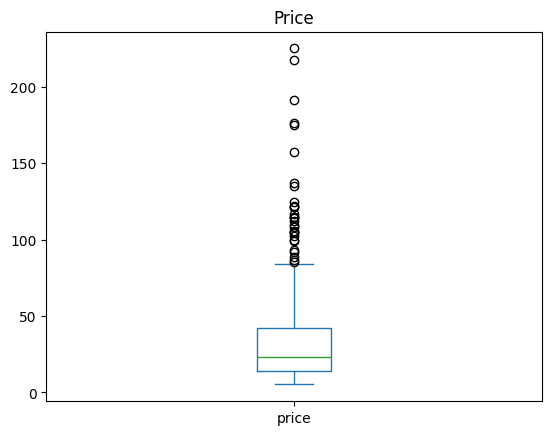

In [ ]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_merge2["price"].plot(kind="box", title="Price")

In [ ]:
#Autre méthode avec plotly express
fig = px.box(df_merge2, y="price", title="Répartition des prix")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [ ]:
#Calculer la moyenne du prix
u = df_merge2["price"].mean()
#Calculer l'écart-type du prix
std = df_merge2["price"].std()
#Calculer le Z-score
df_merge2["z_score"] = (df_merge2["price"] - u) / std

In [ ]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
upper_limit = u + 3 * std
print(f"Le seuil est : {upper_limit}")

Le seuil est : 115.12268073098096


In [ ]:
prix_outliers = df_merge2[df_merge2["z_score"] > 3]["price"]
print(f"Par la méthode du z-score nous avons détecté {len(prix_outliers)} prix en outliers.")

Par la méthode du z-score nous avons détecté 13 prix en outliers.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [ ]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
display(df_merge2[["price","z_score"]].describe())

,price,z_score
count,714.000000,7.140000e+02
mean,32.333683,-3.980632e-17
std,27.596332,1.000000e+00
min,5.200000,-9.832351e-01
25%,14.062500,-6.620874e-01
50%,23.450000,-3.219154e-01
75%,42.075000,3.529932e-01
max,225.000000,6.981591e+00


In [ ]:
#Définir un seuil pour les articles "outliers" en prix
# upper_limit = df_merge2["price"].mean() + 3 * df_merge2["price"].std()
# lower_limit = df_merge2["price"].mean() - 3 * df_merge2["price"].std()
# print(upper_limit)
# print(lower_limit)
q1 = df_merge2["price"].quantile(0.25)
q3 = df_merge2["price"].quantile(0.75)
iqr = q3 - q1
upper_limit2 = q3 + 1.5 * iqr
# lower_limit2 = q1 - 1.5 * iqr
print(upper_limit2)
# print(lower_limit2)

84.09375


In [ ]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
df_merge_outliers = df_merge2[(df_merge2["price"] >= upper_limit2)]
print(f"Nombre d'articles : {len(df_merge_outliers)}")
print(f"Proportion : {round(len(df_merge_outliers) / len(df_merge2),2)}")

Nombre d'articles : 31
Proportion : 0.04


In [ ]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
print("La majorité des prix ont des prix normaux, mais il y a des bouteilles de vin très rare qui coûte extrèment chère.")

La majorité des prix ont des prix normaux, mais il y a des bouteilles de vin très rare qui coûte extrèment chère.


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [ ]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_merge2["ca_par_article"] = df_merge2["total_sales"] * df_merge2["price"]
#Calculer la somme de la colonne "ca_par_article"
sum_ca = df_merge2["ca_par_article"].sum()
#Ce résultat correspond au chiffre d'affaire du site web
print(f"Chiffre d'affaire total est de : {sum_ca} euros")

Chiffre d'affaire total est de : 143680.1 euros


In [ ]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
df_merge2 = df_merge2.sort_values(by="ca_par_article", ascending=False)
#Réinitialiser l'index du dataset par un reset_index
df_merge2.reset_index(drop=True, inplace=True)
#Afficher les 20 premiers articles en CA
df_top20 = df_merge2.head(20)

#Graphique en barre des 20 premiers articles avec plotly express
df_top20["product_id"] = df_top20["product_id"].astype(int).astype(str)

fig = px.bar(
    df_top20,
    x="product_id",                 # axe X : articles
    y="ca_par_article",         # axe Y : métrique
    title="Top 20 articles – Total des ventes",
    labels={
        "product_id": "Article",
        "ca_par_article": "CA par article"
    },
    category_orders={"product_id": df_top20["product_id"].tolist()}
)
fig.show()

/tmp/ipython-input-2064733650.py:13: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_merge2["part_ca"] = df_merge2["ca_par_article"] / df_merge2["ca_par_article"].sum()
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge2["cumsum_ca"] = df_merge2["part_ca"].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nb_articles_80 = (df_merge2["cumsum_ca"] <= 0.80).sum() + 1
print(f"Nombre d'articles : {nb_articles_80}")
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
nb_articles_total = df_merge2["id_web"].nunique()
proportion_catalogue_80 = nb_articles_80 / nb_articles_total * 100
print(f"La proportion est : {round(proportion_catalogue_80,2)} %")
print(f"{round(proportion_catalogue_80,2)} %, le catalogue est très diffus")

Nombre d'articles : 435
La proportion est : 60.92 %
60.92 %, le catalogue est très diffus


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [ ]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_merge2 = df_merge2.sort_values(by="total_sales", ascending=False)
#Réinitialiser l'index du dataset par un reset_index
df_merge2.reset_index(drop=True, inplace=True)
#Afficher les 20 premiers articles en quantité
df_top20 = df_merge2.head(20)
df_top20["product_id"] = df_top20["product_id"].astype(int).astype(str)
#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(
    df_top20,
    x="product_id",                 # axe X : articles
    y="total_sales",         # axe Y : métrique
    title="Top 20 articles – Total des quantitées",
    labels={
        "product_id": "Article",
        "total_sales": "Quantité vendu"
    },
    category_orders={"product_id": df_top20["product_id"].tolist()}
)
fig.show()

/tmp/ipython-input-1827559866.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
###################################
# Calculer le 20 / 80 en quantité #
###################################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_merge2["part_quantite"] = df_merge2["total_sales"] / df_merge2["total_sales"].sum()
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_merge2["cumsum_quantite"] = df_merge2["part_quantite"].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_articles_80 = (df_merge2["cumsum_quantite"] <= 0.80).sum() + 1
print(f"Nombre d'articles : {nb_articles_80}")
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
nb_articles_total = df_merge2["id_web"].nunique()
proportion_catalogue_80 = nb_articles_80 / nb_articles_total * 100
print(f"La proportion est : {round(proportion_catalogue_80,2)} %")
print(f"{round(proportion_catalogue_80,2)} %, le catalogue est très diffus")

Nombre d'articles : 434
La proportion est : 60.78 %
60.78 %, le catalogue est très diffus


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [ ]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Import de numpy
import numpy as np
#Création de la colonne Rotation de stock
df_merge2["rotation_mensuelle"] = df_merge2["total_sales"]
df_merge2["mois_de_stock"] = (
    df_merge2["stock_quantity"] / df_merge2["rotation_mensuelle"]
)

#Remplacement des "inf" par 0
df_merge2["mois_de_stock"] = df_merge2["mois_de_stock"].replace(np.inf, 0)
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
df_merge2 = df_merge2.sort_values(by="mois_de_stock", ascending=False)
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
df_top20 = df_merge2.head(20)
df_top20["product_id"] = df_top20["product_id"].astype(int).astype(str)

fig = px.bar(
    df_top20,
    x="product_id",                 # axe X : articles
    y="mois_de_stock",         # axe Y : métrique
    title="Top 20 articles – Total des mois de stock",
    labels={
        "product_id": "Article",
        "mois_de_stock": "Mois de stock"
    },
    category_orders={"product_id": df_top20["product_id"].tolist()}
)
fig.show()

/tmp/ipython-input-1241267878.py:19: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_merge2["valorisation_stock_euros"] = df_merge2["stock_quantity"] * df_merge2["price"]
#Calculer la somme de la colonne "Valorisation_stock_euros"
sum_stock_quantity_euros = df_merge2["valorisation_stock_euros"].sum()
print(f"Valorisation en euros : {round(sum_stock_quantity_euros)} euros")

Valorisation en euros : 494682 euros


In [ ]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
sum_stock_quantity = df_merge2["stock_quantity"].sum()
print(f"Nombre de produits en stock : {sum_stock_quantity}")

Nombre de produits en stock : 16741.0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [ ]:
############################
# Analyse du taux de marge #
############################

TVA = 0.20

#Création de la colonne Prix HT
df_merge2["prix_vente_ht"] = (
    df_merge2["price"] / (1 + TVA)
)
#Création de la colonne Taux de marge
df_merge2["taux_marge"] = (
    (df_merge2["prix_vente_ht"] - df_merge2["purchase_price"])
    / df_merge2["prix_vente_ht"]
)

#Afficher le prix minimum de la colonne "taux_marge"
taux_marge_min = df_merge2["taux_marge"].min()
print(f"Taux de marge minimum : {taux_marge_min:.2%}")
#Afficher le prix maximum de la colonne "taux_marge"
taux_marge_max = df_merge2["taux_marge"].max()
print(f"Taux de marge maximum : {taux_marge_max:.2%}")

Taux de marge minimum : -634.99%
Taux de marge maximum : 47.76%


In [ ]:
#Affichage de la ligne avec un taux de marge inférieur à 0
df_merge2[df_merge2["taux_marge"] < 0]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,total_sales,product_type,post_type,z_score,ca_par_article,part_ca,cumsum_ca,part_quantite,cumsum_quantite,rotation_mensuelle,mois_de_stock,valorisation_stock_euros,prix_vente_ht,taux_marge
701,4355.0,1.0,12.65,97.0,instock,77.48,12589,0.0,Champagne,product,-0.713272,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1227.05,10.541667,-6.349881


In [ ]:
#Création d'un dataframe avec les taux positifs
df_pos_marge = df_merge2[df_merge2["taux_marge"] > 0]
#Afficher le prix minimum de la colonne "taux_marge"
taux_marge_min = df_pos_marge["taux_marge"].min()
print(f"Taux de marge minimum : {taux_marge_min:.2%}")
#Afficher le prix maximum de la colonne "taux_marge"
taux_marge_max = df_pos_marge["taux_marge"].max()
print(f"Taux de marge maximum : {taux_marge_max:.2%}")

Taux de marge minimum : 22.78%
Taux de marge maximum : 47.76%


In [ ]:
df_marge_par_type = (
    df_merge2
    .groupby("product_type", as_index=False)["taux_marge"]
    .mean()
)
df_marge_par_type

,product_type,taux_marge
0,Champagne,0.047929
1,Cognac,0.450676
2,Gin,0.428000
3,Huile d'olive,0.249982
4,Vin,0.380123
5,Whisky,0.449189


In [ ]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_marge_par_type = (
    df_merge2
    .groupby("product_type", as_index=False)["taux_marge"]
    .mean()
)
#Affichage dans un graphique du taux de marge par type de produit
fig = px.bar(
    df_marge_par_type,
    x="product_type",
    y="taux_marge",
    title="Taux de marge moyen par type de produit",
    labels={
        "product_type": "Type de produit",
        "taux_marge": "Taux de marge moyen"
    }
)

fig.update_yaxes(tickformat=".0%")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

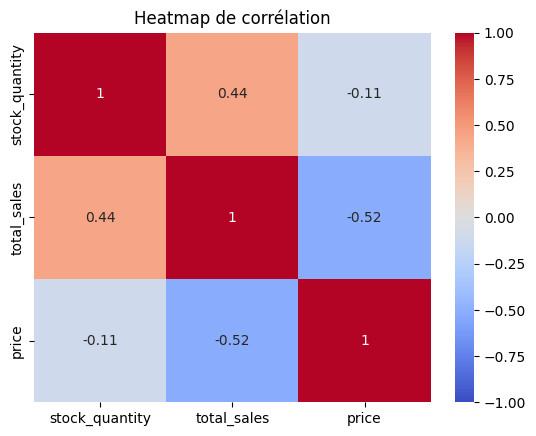

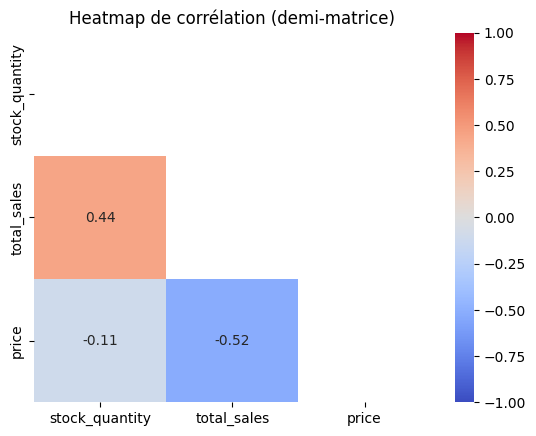

In [ ]:
############################
# Analyse des corrélations #
############################

#Importation de Seaborn
import seaborn as sns
import matplotlib.pyplot as plt
#Création d'une heatmap de corrélation avec les variables stock, sales et price
correlation = df_merge2[["stock_quantity", "total_sales", "price"]].corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(
    correlation,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    annot=True
)
plt.title("Heatmap de corrélation")
plt.show()
#On peut également créer un mask pour n'afficher qu'une demi heatmap
sns.heatmap(
    correlation,
    mask=mask,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    annot=True
)
plt.title("Heatmap de corrélation (demi-matrice)")
plt.show()

In [ ]:
#Que peut-on conclure des corrélations ?

Les corrélations observées entre le stock, les ventes et le prix restent modérées, suggérant une relation partielle entre disponibilité produit, performance commerciale et positionnement tarifaire. Cela indique une gestion des stocks relativement stable, avec des marges d’optimisation possibles sur l’ajustement prix–volume.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [ ]:
#Mettre le dataset df_merge sur un fichier Excel
#Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes.
df_merge2.to_csv("df_merge.csv")